# The cuts are rectangles

A question on length is a vertical line. A question on weight is a horizontal line. The leaves are rectangles, including rectangles that run off to the edge of the page.

With the tie-break used in this path, the pass leaf is

$$
\text{length} \le \frac{7}{2}
\quad\text{and}\quad
\text{weight} \le 3
$$

The other three combinations fail: short and heavy, long and light, long and heavy. Two of those failure regions contain training parts. The long-and-heavy region contains none. It still gets a label, borrowed from the long-and-light leaf's sibling logic: length already failed the first test, so weight is never asked, and the leaf says fail.


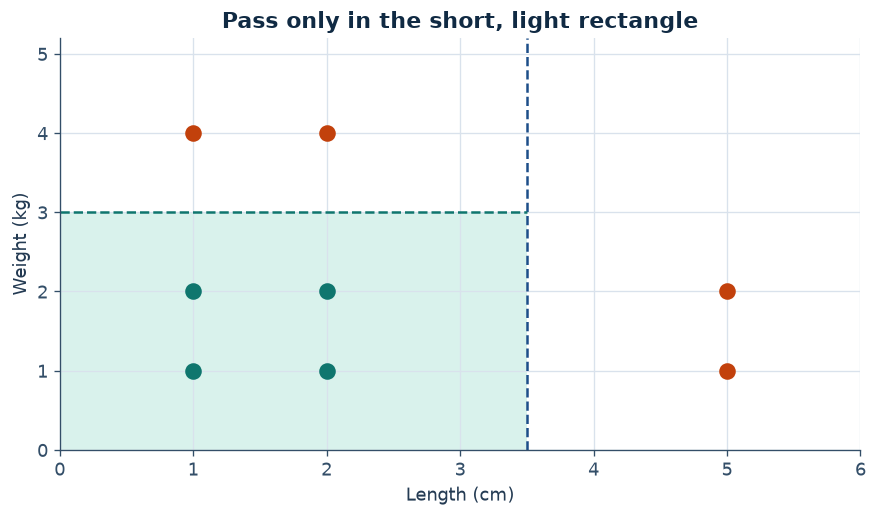

In [1]:
import matplotlib.pyplot as plt

# Quiet page. Pass is green, fail is clay, and the grid stays behind the marks.
plt.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#d9e2ec",
    "axes.edgecolor": "#334e68",
    "axes.labelcolor": "#243b53",
    "xtick.color": "#334e68",
    "ytick.color": "#334e68",
    "text.color": "#102a43",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 11,
    "savefig.facecolor": "white",
})
BLUE = "#1d4e89"
CLAY = "#c2410c"
GREEN = "#0f766e"
INK = "#102a43"
GRAY = "#9fb3c8"

# Pass is the lower-left rectangle. The other three regions fail.
parts = [
    (1, 1, "pass"), (1, 2, "pass"), (2, 1, "pass"), (2, 2, "pass"),
    (1, 4, "fail"), (2, 4, "fail"), (5, 1, "fail"), (5, 2, "fail"),
]
fig, ax = plt.subplots(constrained_layout=True)
ax.add_patch(plt.Rectangle((0, 0), 3.5, 3, facecolor="#d9f2ec", edgecolor="none", zorder=0))
ax.axvline(3.5, color=BLUE, linestyle="--")
ax.plot([0, 3.5], [3, 3], color=GREEN, linestyle="--")
for length, weight, label in parts:
    ax.scatter(
        length,
        weight,
        s=80,
        color=GREEN if label == "pass" else CLAY,
        zorder=3,
    )
ax.set_xlim(0, 6)
ax.set_ylim(0, 5.2)
ax.set_xlabel("Length (cm)")
ax.set_ylabel("Weight (kg)")
ax.set_title("Pass only in the short, light rectangle")


# XOR needs a cut that gains nothing

Four points, two features, labels that alternate:

| $x$ | $y$ | label |
|---:|---:|---|
| 0 | 0 | fail |
| 0 | 1 | pass |
| 1 | 0 | pass |
| 1 | 1 | fail |

Parent Gini is $1/2$. Cut at $x \le 1/2$. Each side has one pass and one fail, so each side has Gini $1/2$. The gain is

$$
\frac{1}{2} - \frac{1}{2} = 0
$$

The cut on $y$ has the same gain, $0$. A rule that stops when the best gain is $0$ predicts the tie-break label for every point and gets two of the four wrong.

Force the $x$ cut anyway. The left child is $(0,0)$ fail and $(0,1)$ pass. Now $y \le 1/2$ separates them, and the local gain is $1/2$. The right child separates the same way. Depth two is pure. The first question was necessary and, by itself, worth nothing.


In [2]:
# First XOR cut gains 0. Each second cut gains 1/2 inside its own node.
from fractions import Fraction

rows = [(0, 0, "fail"), (0, 1, "pass"), (1, 0, "pass"), (1, 1, "fail")]

def gini(labels):
    n = len(labels)
    counts = {}
    for label in labels:
        counts[label] = counts.get(label, 0) + 1
    return 1 - sum(Fraction(c, n) ** 2 for c in counts.values())

parent = gini([row[2] for row in rows])
left = [row[2] for row in rows if row[0] <= Fraction(1, 2)]
right = [row[2] for row in rows if row[0] > Fraction(1, 2)]
gain = parent - (
    Fraction(len(left), 4) * gini(left) + Fraction(len(right), 4) * gini(right)
)
assert gain == 0
assert gini(left) == Fraction(1, 2)
# Inside the left child, y <= 1/2 is pure on both sides.
left_rows = [row for row in rows if row[0] <= Fraction(1, 2)]
low = [row[2] for row in left_rows if row[1] <= Fraction(1, 2)]
high = [row[2] for row in left_rows if row[1] > Fraction(1, 2)]
assert low == ["fail"] and high == ["pass"]
assert gini(left) - 0 == Fraction(1, 2)
print("first gain", gain)


first gain 0


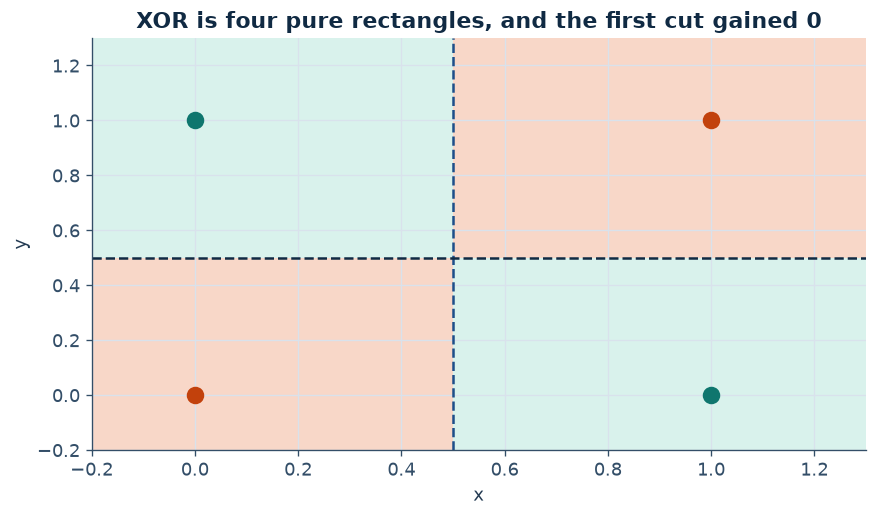

In [3]:
import matplotlib.pyplot as plt

# Quiet page. Pass is green, fail is clay, and the grid stays behind the marks.
plt.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#d9e2ec",
    "axes.edgecolor": "#334e68",
    "axes.labelcolor": "#243b53",
    "xtick.color": "#334e68",
    "ytick.color": "#334e68",
    "text.color": "#102a43",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 11,
    "savefig.facecolor": "white",
})
BLUE = "#1d4e89"
CLAY = "#c2410c"
GREEN = "#0f766e"
INK = "#102a43"
GRAY = "#9fb3c8"

# Two cuts after a zero-gain first question. Each rectangle is pure.
fig, ax = plt.subplots(constrained_layout=True)
# Data coordinates, not axes fractions: each leaf is one rectangle.
ax.add_patch(plt.Rectangle((-0.2, -0.2), 0.7, 0.7, facecolor="#f8d7c8", edgecolor="none", zorder=0))
ax.add_patch(plt.Rectangle((-0.2, 0.5), 0.7, 1.0, facecolor="#d9f2ec", edgecolor="none", zorder=0))
ax.add_patch(plt.Rectangle((0.5, -0.2), 1.0, 0.7, facecolor="#d9f2ec", edgecolor="none", zorder=0))
ax.add_patch(plt.Rectangle((0.5, 0.5), 1.0, 1.0, facecolor="#f8d7c8", edgecolor="none", zorder=0))
points = [(0, 0, CLAY), (0, 1, GREEN), (1, 0, GREEN), (1, 1, CLAY)]
for x, y, color in points:
    ax.scatter(x, y, s=90, color=color, zorder=3)
ax.axvline(0.5, color=BLUE, linestyle="--")
ax.axhline(0.5, color=INK, linestyle="--")
ax.set_xlim(-0.2, 1.3)
ax.set_ylim(-0.2, 1.3)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("XOR is four pure rectangles, and the first cut gained 0")


## A pitfall

Rectangles have sides parallel to the axes. A boundary that runs diagonally is a staircase of rectangles, or it is not represented. Looking at a scatter and seeing a diagonal is a reason to doubt that one shallow tree is the whole model.

## What to carry forward

The pass leaf of the eight parts is the rectangle length $\le 7/2$, weight $\le 3$. XOR's first cut gains $0$, and a second cut on the other feature finishes the separation.
